<a href="https://colab.research.google.com/github/ayush-singh110/Kaggle_Heart_prediction_Contest/blob/main/Kaggle_Heart_Prediction_Competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import QuantileTransformer,StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
!pip install xgboost
from xgboost import XGBClassifier
!pip install lightgbm
from lightgbm import LGBMClassifier
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from mlxtend.classifier import StackingClassifier

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization,Activation
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df=pd.read_csv('train.csv')
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [ ]:
df.drop('id',inplace=True,axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest pain type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS over 120             630000 non-null  int64  
 6   EKG results              630000 non-null  int64  
 7   Max HR                   630000 non-null  int64  
 8   Exercise angina          630000 non-null  int64  
 9   ST depression            630000 non-null  float64
 10  Slope of ST              630000 non-null  int64  
 11  Number of vessels fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  Heart Disease            630000 non-null  object 
dtypes: f

In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [ ]:
df['Age'].unique()

array([58, 52, 56, 44, 38, 59, 60, 48, 41, 42, 53, 50, 65, 46, 62, 57, 54,
       66, 51, 55, 43, 71, 63, 61, 35, 49, 47, 67, 64, 45, 40, 70, 69, 37,
       76, 34, 68, 39, 74, 77, 29, 75])

In [ ]:
df['Sex'].unique()

array([1, 0])

In [ ]:
df['Chest pain type'].unique()

array([4, 1, 2, 3])

In [ ]:
df['BP'].unique()

array([152, 125, 160, 134, 140, 138, 130, 120, 150, 108, 110, 178, 124,
        94, 112, 128, 118, 100, 105, 172, 180, 145, 132, 142, 122, 135,
       136, 126, 106, 101, 115, 156, 170, 146, 192, 102, 117, 148, 104,
       200, 165, 129, 174, 123, 144, 158, 133, 103, 147, 155, 149, 109,
       168, 111, 154, 127, 114, 116, 175, 141, 131, 162,  99,  96,  95,
       184])

In [ ]:
df['Cholesterol'].unique()

array([239, 325, 188, 229, 234, 283, 246, 245, 212, 197, 230, 263, 244,
       231, 274, 282, 199, 226, 204, 185, 177, 250, 211, 303, 201, 266,
       256, 219, 222, 249, 235, 295, 258, 271, 304, 277, 203, 228, 269,
       208, 254, 268, 206, 299, 221, 196, 240, 298, 288, 265, 198, 270,
       243, 309, 233, 330, 255, 315, 261, 294, 223, 214, 273, 286, 267,
       260, 236, 289, 252, 275, 302, 224, 305, 218, 340, 248, 308, 300,
       149, 209, 225, 213, 207, 180, 192, 327, 232, 200, 341, 227, 322,
       220, 311, 210, 172, 247, 360, 306, 318, 215, 335, 205, 178, 182,
       242, 168, 564, 353, 195, 253, 407, 276, 313, 354, 257, 307, 409,
       217, 175, 290, 321, 184, 174, 281, 319, 186, 417, 193, 293, 164,
       166, 160, 216, 183, 326, 237, 158, 259, 262, 170, 464, 150, 264,
       165, 284, 138, 173, 130, 126, 202])

In [ ]:
df['FBS over 120'].unique()

array([0, 1])

In [ ]:
df['EKG results'].unique()

array([0, 2, 1])

In [ ]:
df['Max HR'].unique()

array([158, 171, 151, 150, 125, 147, 152, 173, 160, 142, 161, 163, 162,
       169, 172, 145, 166,  96, 122, 132, 168, 131, 140, 143, 154, 105,
       159, 170, 149, 139, 178, 174, 165, 181, 148, 156, 155, 175, 182,
       120, 126, 146, 138, 180, 157, 164, 114,  99, 144, 179, 153, 141,
       192, 109, 130, 116, 106, 167, 108, 112, 117, 194, 129, 186, 133,
       188, 111, 103, 123, 134, 177,  95, 202, 121, 113,  97, 184, 185,
       190, 115,  88, 118, 136, 195, 124, 128,  71, 187, 127, 137, 110,
        94, 201])

In [ ]:
df['Exercise angina'].unique()

array([1, 0])

In [ ]:
df['ST depression'].unique()

array([3.6 , 0.  , 1.  , 3.8 , 1.6 , 0.8 , 1.2 , 0.6 , 0.2 , 1.8 , 2.2 ,
       0.3 , 1.4 , 1.5 , 2.8 , 3.  , 0.9 , 1.1 , 3.2 , 1.9 , 4.  , 2.  ,
       1.3 , 2.6 , 0.5 , 0.4 , 0.1 , 2.5 , 2.4 , 4.9 , 3.9 , 2.3 , 3.4 ,
       2.1 , 3.5 , 4.3 , 4.2 , 4.5 , 3.1 , 4.6 , 2.9 , 2.7 , 4.8 , 5.  ,
       4.4 , 6.  , 0.7 , 3.3 , 5.4 , 1.7 , 2.12, 3.7 , 4.1 , 5.2 , 6.2 ,
       6.1 , 5.6 , 0.64, 5.8 , 4.7 , 5.1 , 1.64, 5.5 , 5.9 , 5.3 , 0.06])

In [ ]:
df['Slope of ST'].unique()

array([2, 1, 3])

In [ ]:
df['Number of vessels fluro'].unique()

array([2, 0, 3, 1])

In [ ]:
df['Thallium'].unique()

array([7, 3, 6])

In [ ]:
df['Heart Disease'].unique()

array(['Presence', 'Absence'], dtype=object)

In [ ]:
df['Heart Disease']=df['Heart Disease'].map({'Presence':1,'Absence':0})

In [ ]:
df['Heart Disease'].value_counts()

,count
Heart Disease,
0,347546
1,282454


In [ ]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1.0
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0.0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0.0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0.0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1.0


In [ ]:
df.corr()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
Age,1.000000,0.088279,0.109547,-0.003872,0.019380,0.013351,0.057538,-0.097466,0.110075,0.103041,0.096345,0.102873,0.150058,0.211875
Sex,0.088279,1.000000,0.195836,-0.003372,0.038290,0.020485,0.093589,-0.176141,0.192768,0.181005,0.169788,0.174729,0.275409,0.342491
Chest pain type,0.109547,0.195836,1.000000,-0.003539,0.045414,0.023051,0.120892,-0.221845,0.246187,0.240326,0.233714,0.236742,0.319937,0.460720
BP,-0.003872,-0.003372,-0.003539,1.000000,-0.004634,-0.000744,-0.003611,0.004488,-0.003190,-0.003960,-0.003292,-0.003220,-0.005794,-0.005221
Cholesterol,0.019380,0.038290,0.045414,-0.004634,1.000000,0.006219,0.024956,-0.048641,0.049828,0.044635,0.040280,0.048926,0.061814,0.082804
FBS over 120,0.013351,0.020485,0.023051,-0.000744,0.006219,1.000000,0.016209,-0.025050,0.027960,0.031392,0.030367,0.025941,0.033024,0.033485
EKG results,0.057538,0.093589,0.120892,-0.003611,0.024956,0.016209,1.000000,-0.125151,0.128945,0.149465,0.144593,0.131088,0.169083,0.219129
Max HR,-0.097466,-0.176141,-0.221845,0.004488,-0.048641,-0.025050,-0.125151,1.000000,-0.236246,-0.229436,-0.206325,-0.236404,-0.306993,-0.441065
Exercise angina,0.110075,0.192768,0.246187,-0.003190,0.049828,0.027960,0.128945,-0.236246,1.000000,0.281286,0.245301,0.270505,0.357064,0.441921
ST depression,0.103041,0.181005,0.240326,-0.003960,0.044635,0.031392,0.149465,-0.229436,0.281286,1.000000,0.438382,0.293731,0.317089,0.430745


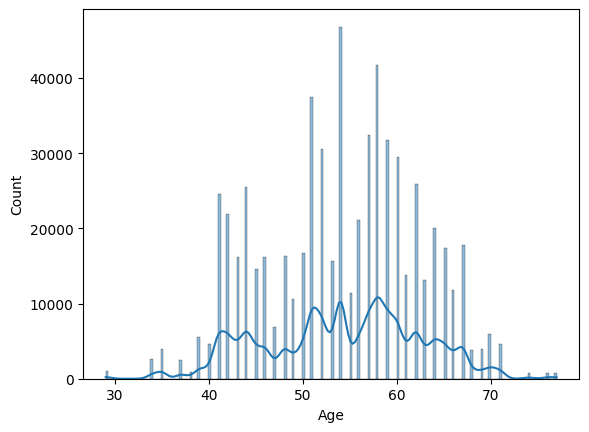

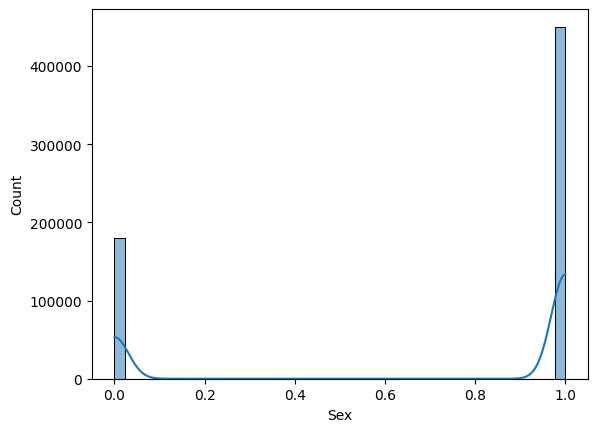

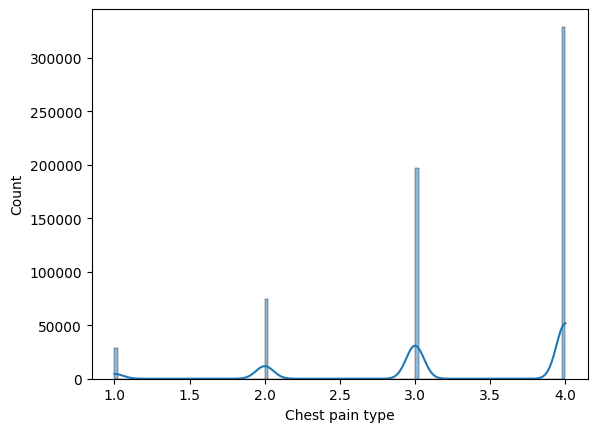

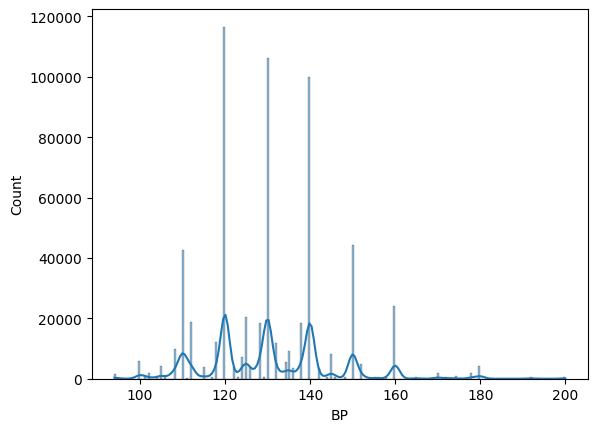

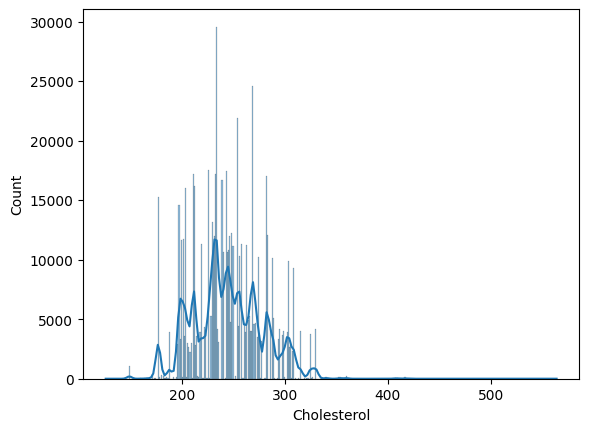

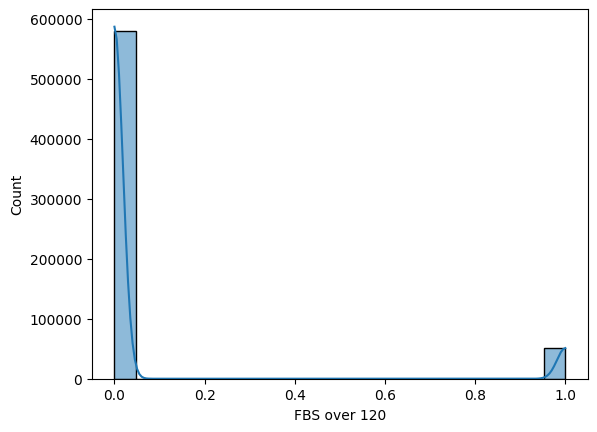

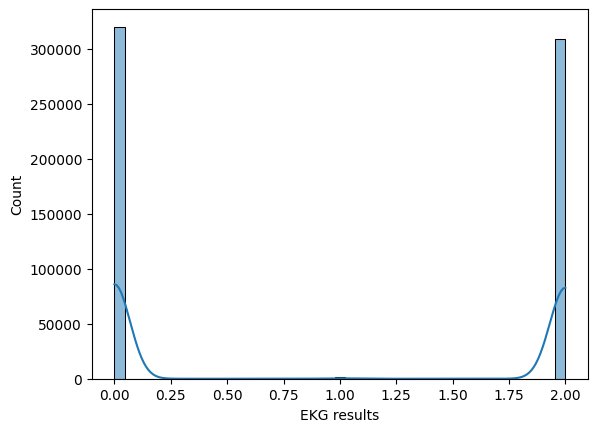

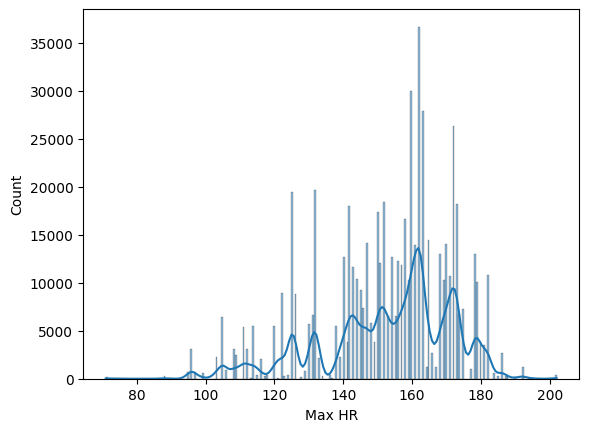

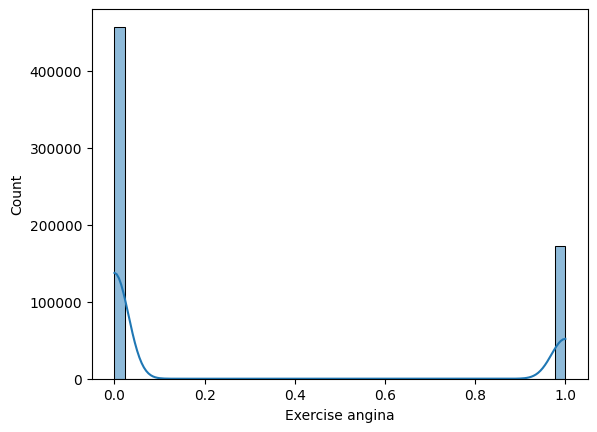

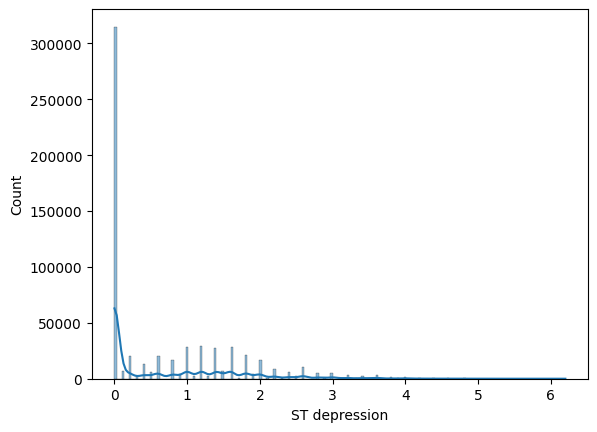

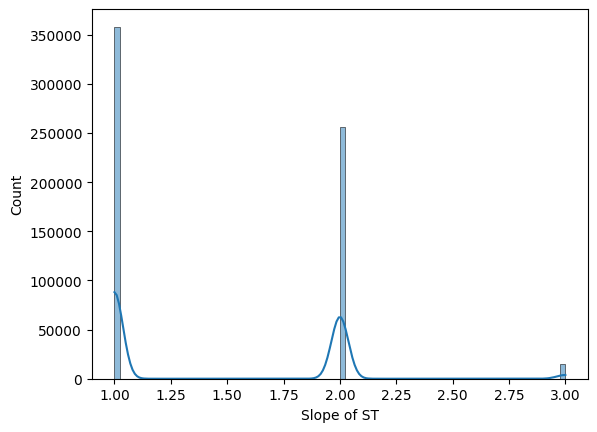

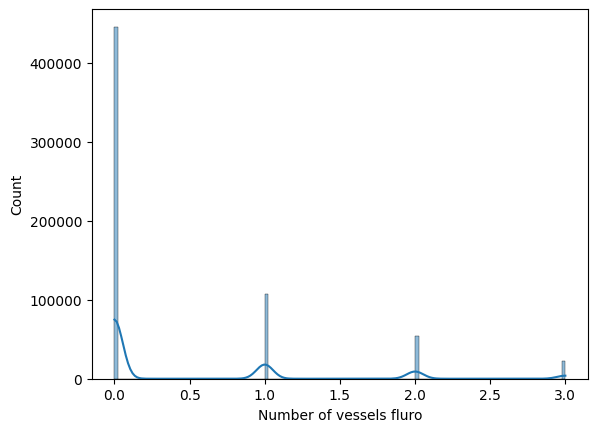

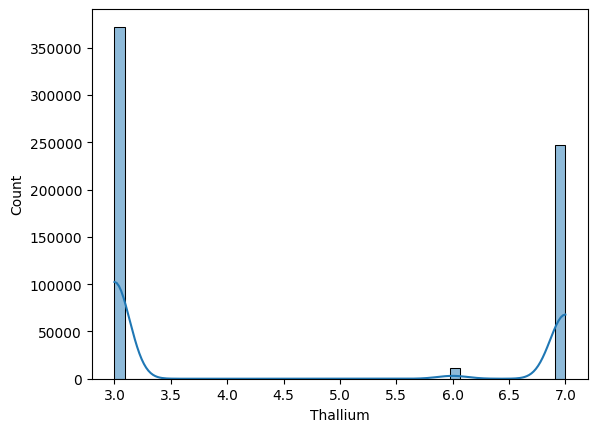

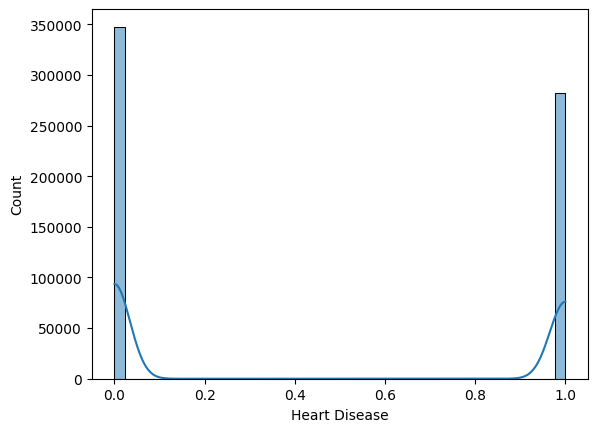

In [ ]:
for i in df.columns:
    sns.histplot(x=i,data=df,kde=True)
    plt.show()

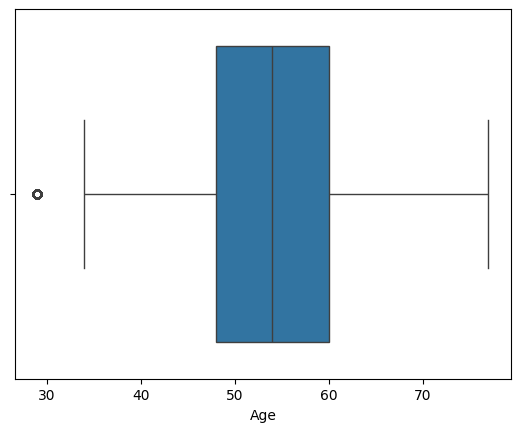

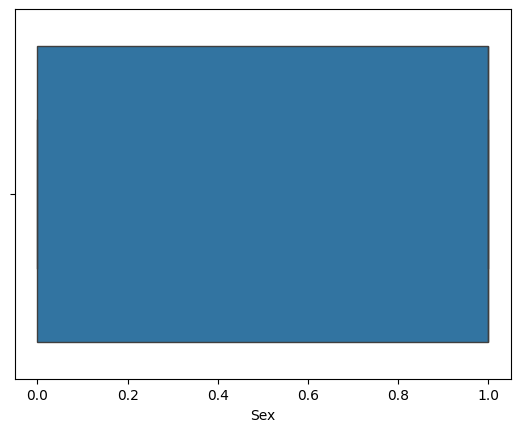

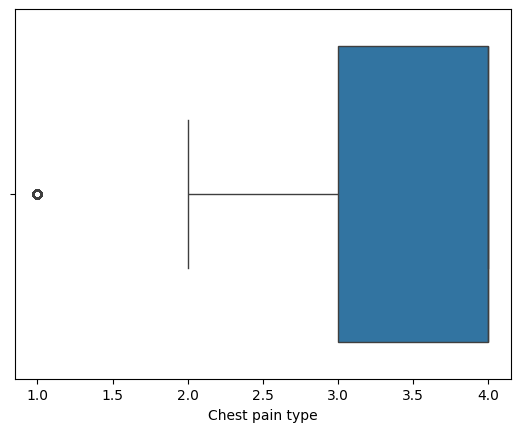

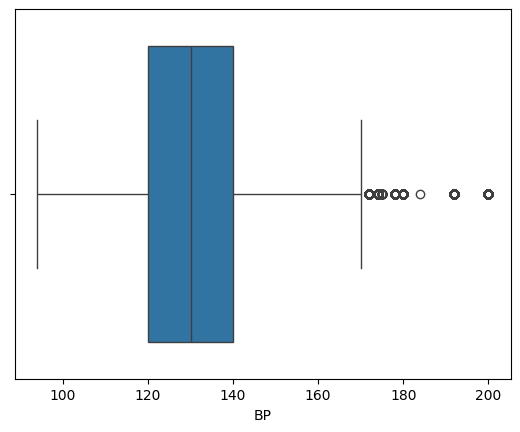

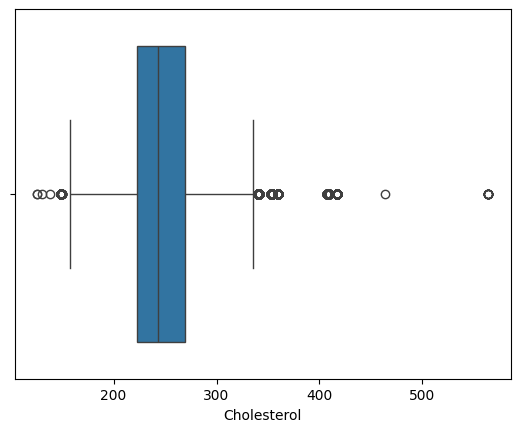

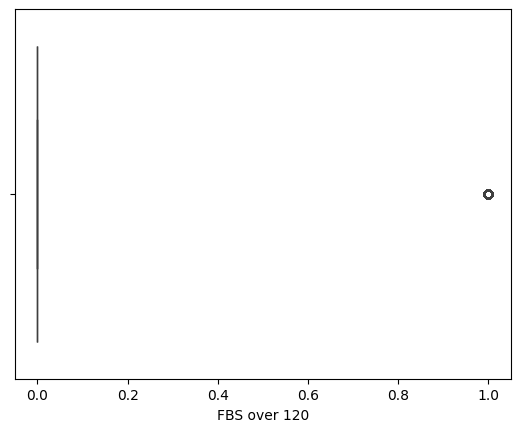

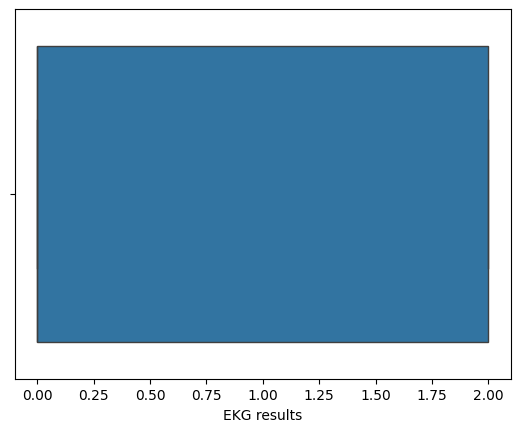

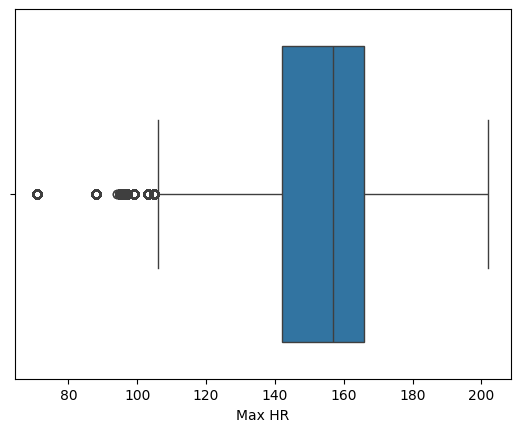

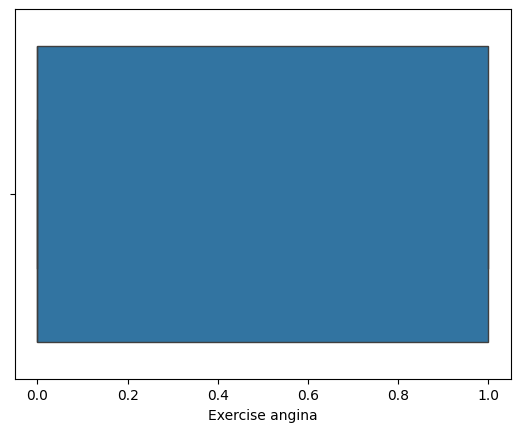

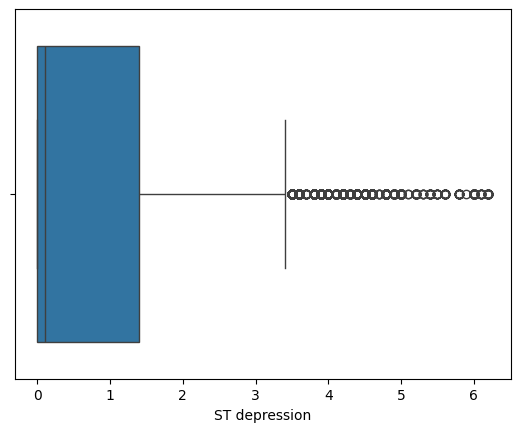

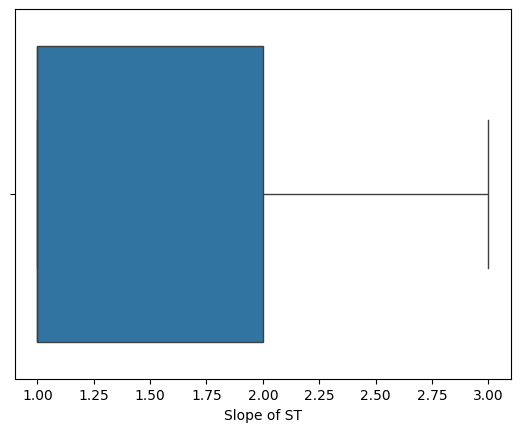

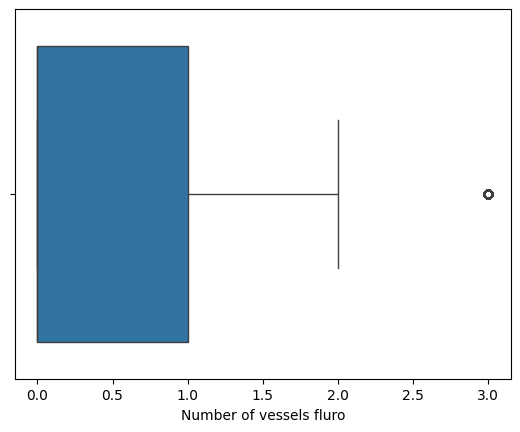

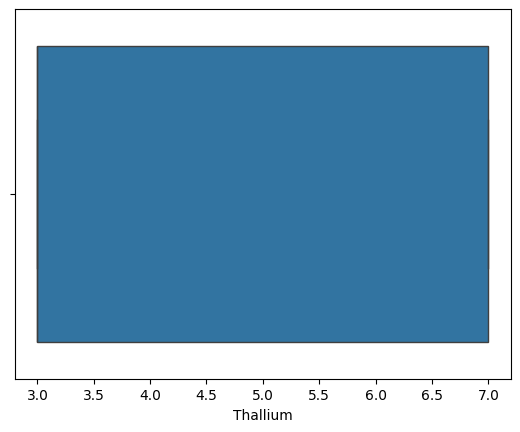

In [ ]:
for i in df.columns:
  if i!='Heart Disease':
    sns.boxplot(x=i,data=df)
    plt.show()

In [ ]:
X=df.drop('Heart Disease',axis=1)
y=df['Heart Disease']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [ ]:
mm=MinMaxScaler()
qt=QuantileTransformer(output_distribution='normal')
ct=ColumnTransformer(
    [   ('qt',qt,['BP','Cholesterol','Max HR','ST depression']),
        ('mm',mm,X_test.columns)
    ]
)

In [ ]:
X_train_ct=ct.fit_transform(X_train)
X_test_ct=ct.transform(X_test)

In [ ]:
lg=LogisticRegression()
lg.fit(X_train_ct,y_train)
y_pred_proba=lg.predict_proba(X_test_ct)
print(roc_auc_score(y_test,y_pred_proba[:,1]))

0.950306113056468


In [ ]:
models={
    'LogReg':LogisticRegression(),
    'RandomForest':RandomForestClassifier(),
    'GradientBoosting':GradientBoostingClassifier(),
    'AdaBoost':AdaBoostClassifier(),
    'XGBoost':XGBClassifier(),
    'LightGBM':LGBMClassifier(),
    'CatBoost':CatBoostClassifier()
}

In [ ]:
for i in models.keys():
  model=models[i]
  model.fit(X_train_ct,y_train)
  print(i)
  y_pred_proba=model.predict_proba(X_test_ct)
  print(roc_auc_score(y_test,y_pred_proba[:,1]))
  print("_______________________________________")

LogReg
0.950306113056468
_______________________________________
RandomForest
0.946464117455342
_______________________________________
GradientBoosting
0.9535848012689111
_______________________________________
AdaBoost
0.9526010781955525
_______________________________________
XGBoost
0.9545468912433857
_______________________________________
[LightGBM] [Info] Number of positive: 211915, number of negative: 260585
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052597 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 770
[LightGBM] [Info] Number of data points in the train set: 472500, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448497 -> initscore=-0.206744
[LightGBM] [Info] Start training from score -0.206744
LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9546546851291915
_______________________________________
Learning rate set to 0.142858
0:	learn: 0.5540272	total: 204ms	remaining: 3m 23s
1:	learn: 0.4668150	total: 420ms	remaining: 3m 29s
2:	learn: 0.4097655	total: 638ms	remaining: 3m 32s
3:	learn: 0.3741171	total: 834ms	remaining: 3m 27s
4:	learn: 0.3484661	total: 1.07s	remaining: 3m 32s
5:	learn: 0.3318811	total: 1.29s	remaining: 3m 34s
6:	learn: 0.3192019	total: 1.51s	remaining: 3m 34s
7:	learn: 0.3101634	total: 1.73s	remaining: 3m 35s
8:	learn: 0.3036384	total: 1.94s	remaining: 3m 33s
9:	learn: 0.2985293	total: 2.15s	remaining: 3m 32s
10:	learn: 0.2941229	total: 2.35s	remaining: 3m 30s
11:	learn: 0.2904752	total: 2.57s	remaining: 3m 31s
12:	learn: 0.2875972	total: 2.72s	remaining: 3m 26s
13:	learn: 0.2851659	total: 2.82s	remaining: 3m 18s
14:	learn: 0.2831745	total: 2.92s	remaining: 3m 11s
15:	learn: 0.2815327	total: 3.02s	remaining: 3m 5s
16:	learn: 0.2801062	total: 3.12s	remaining: 3m
17:	learn: 0.2790278	total: 3.24s	remainin

In [ ]:
y_test_cleaned = y_test.dropna()
X_test_ct_cleaned = X_test_ct[y_test.notna().values]

In [ ]:
cb=CatBoostClassifier(iterations=800,learning_rate=0.48,depth=5,eval_metric='AUC',random_state=42,verbose=True)
cb.fit(X_train_ct,y_train)

0:	total: 162ms	remaining: 2m 9s
1:	total: 308ms	remaining: 2m 2s
2:	total: 550ms	remaining: 2m 26s
3:	total: 707ms	remaining: 2m 20s
4:	total: 891ms	remaining: 2m 21s
5:	total: 1.06s	remaining: 2m 20s
6:	total: 1.27s	remaining: 2m 24s
7:	total: 1.51s	remaining: 2m 29s
8:	total: 1.73s	remaining: 2m 32s
9:	total: 1.96s	remaining: 2m 34s
10:	total: 2.31s	remaining: 2m 45s
11:	total: 2.64s	remaining: 2m 53s
12:	total: 3.01s	remaining: 3m 2s
13:	total: 3.24s	remaining: 3m 1s
14:	total: 3.56s	remaining: 3m 6s
15:	total: 3.76s	remaining: 3m 4s
16:	total: 4.05s	remaining: 3m 6s
17:	total: 4.27s	remaining: 3m 5s
18:	total: 4.37s	remaining: 2m 59s
19:	total: 4.54s	remaining: 2m 57s
20:	total: 4.69s	remaining: 2m 54s
21:	total: 4.83s	remaining: 2m 50s
22:	total: 4.97s	remaining: 2m 47s
23:	total: 5.17s	remaining: 2m 47s
24:	total: 5.33s	remaining: 2m 45s
25:	total: 5.48s	remaining: 2m 43s
26:	total: 5.65s	remaining: 2m 41s
27:	total: 5.81s	remaining: 2m 40s
28:	total: 5.99s	remaining: 2m 39s
29:

CatBoostClassifier(depth=5, eval_metric='AUC', iterations=800, learning_rate=0.48, random_state=42, verbose=True)

In [ ]:
roc_auc_score(y_test,cb.predict_proba(X_test_ct)[:,1])

np.float64(0.9539710285535274)

In [ ]:
xg = XGBClassifier(
    n_estimators=4000,
    learning_rate=0.01,
    max_depth=4,
    random_state=42,
)
xg.fit(X_train_ct,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=4000,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print(roc_auc_score(y_test,xg.predict_proba(X_test_ct)[:,1]))

0.9552326993016933


In [ ]:
base_learners=[
    XGBClassifier(),
    RandomForestClassifier(),
    GradientBoostingClassifier()

]
meta_model=LogisticRegression()
stack_model=StackingClassifier(classifiers=base_learners,meta_classifier=meta_model)
stack_model.fit(X_train_ct,y_train)

# Filter out NaN values from y_test and corresponding rows from X_test_ct
y_test_cleaned = y_test.dropna()
X_test_ct_cleaned = X_test_ct[y_test.notna().values]

print(roc_auc_score(y_test_cleaned, stack_model.predict_proba(X_test_ct_cleaned)[:,1]))

0.899576178115994


In [ ]:
mode=Sequential(
    [Dense(128,activation='relu',input_shape=(X_train_ct.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dense(40,activation='relu'),
    BatchNormalization(),
    Activation('relu'),
    Dense(1,activation='sigmoid')]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
mode.compile(optimizer='adam',loss='binary_crossentropy',metrics=[tf.keras.metrics.AUC()])

In [ ]:
early_stop=EarlyStopping(monitor='val_loss',restore_best_weights=True)

In [ ]:
history=mode.fit(X_train_ct,y_train,validation_data=(X_test_ct,y_test),callbacks=[early_stop],epochs=50)

Epoch 1/50
14670/14670 ━━━━━━━━━━━━━━━━━━━━ 67s 4ms/step - auc_8: 0.9429 - loss: 0.3018 - val_auc_8: 0.9519 - val_loss: nan
Epoch 2/50
14670/14670 ━━━━━━━━━━━━━━━━━━━━ 55s 4ms/step - auc_8: 0.9501 - loss: 0.2831 - val_auc_8: 0.9519 - val_loss: nan


In [ ]:
test_df=pd.read_csv('test.csv')
test_df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [ ]:
test_df.drop('id',axis=1,inplace=True)

In [ ]:
test_df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [ ]:
test_df['Cholesterol']=test_df['Cholesterol'].fillna(test_df['Cholesterol'].mean())

In [ ]:
test_df['FBS over 120']=test_df['FBS over 120'].fillna(test_df['FBS over 120'].mode()[0])

In [ ]:
test_df['EKG results']=test_df['EKG results'].fillna(test_df['EKG results'].mode()[0])

In [ ]:
test_df['Max HR']=test_df['Max HR'].fillna(test_df['Max HR'].mean())

In [ ]:
test_df['Exercise angina']=test_df['Exercise angina'].fillna(test_df['Exercise angina'].mode()[0])

In [ ]:
test_df['ST depression']=test_df['ST depression'].fillna(test_df['ST depression'].mean())

In [ ]:
test_df['Slope of ST']=test_df['Slope of ST'].fillna(test_df['Slope of ST'].mode()[0])

In [ ]:
test_df['Number of vessels fluro']=test_df['Number of vessels fluro'].fillna(test_df['Number of vessels fluro'].mode()[0])

In [ ]:
test_df['Thallium']=test_df['Thallium'].fillna(test_df['Thallium'].mode()[0])

In [ ]:
test_df_ct=ct.transform(test_df)

In [ ]:
sample=pd.read_csv('sample_submission.csv')
sample.head()

,id,Heart Disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


In [ ]:
y_predict_proba=cb.predict_proba(test_df_ct)[:,1]

In [ ]:
sample_df=pd.DataFrame(
    {"id":sample['id'],
    "Heart Disease":y_predict_proba}
)

In [ ]:
sample_df.to_csv('submission.csv', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')